# Tamil Nadu hourly peak-week results analysis

This notebook analyzes the solved 168-snapshot hourly peak week in `tamil_nadu_2025_26.nc`.

In [23]:
import pandas as pd
import pypsa

RESULT_FILE = "tamil_nadu_2025_26.nc"
n = pypsa.Network(RESULT_FILE)

assert len(n.snapshots) == 168, f"Expected 168 hourly snapshots, found {len(n.snapshots)}"
assert (n.snapshots.to_series().diff().dropna() == pd.Timedelta(hours=1)).all()
assert (n.snapshot_weightings[["objective", "stores", "generators"]] == 1.0).all().all()
print(f"Loaded solved hourly peak week from {RESULT_FILE}")

INFO:pypsa.network.io:Imported network 'Tamil Nadu FY 2025-26 single-node UC inputs' has buses, carriers, generators, loads, storage_units, sub_networks


Loaded solved hourly peak week from tamil_nadu_2025_26.nc


In [24]:
n

PyPSA Network 'Tamil Nadu FY 2025-26 single-node UC inputs'
-----------------------------------------------------------
Components:
 - Bus: 1
 - Carrier: 12
 - Generator: 278
 - Load: 1
 - StorageUnit: 4
 - SubNetwork: 1
Snapshots: 168

## Dispatch, storage, and coal commitment

This four-panel figure shows how supply meets demand during the peak-demand week at hourly resolution:

1. **Total system dispatch:** The stacked areas show generation and storage discharge by carrier. The height of the stack is total supply, while the black line is demand. Coal is grey, solar yellow, wind light blue, hydro blue, and unserved energy red. A visible red area would indicate that available supply could not fully meet demand.
2. **Total storage operation:** The graph aggregates all storage units. The positive line is total discharge supplied to the system, while the negative line is total charging demand. Keeping the two totals separate preserves any simultaneous charging and discharging by different units.
3. **Total storage state of charge:** This is the sum of the energy held in all storage units in MWh. Rising values indicate net charging and falling values indicate net discharge.
4. **Coal unit commitment:** The grey line and left axis show total coal generation in MW. The dashed red line and right axis show the percentage of coal units that are online. This percentage is based on the number of units, not their installed capacity.


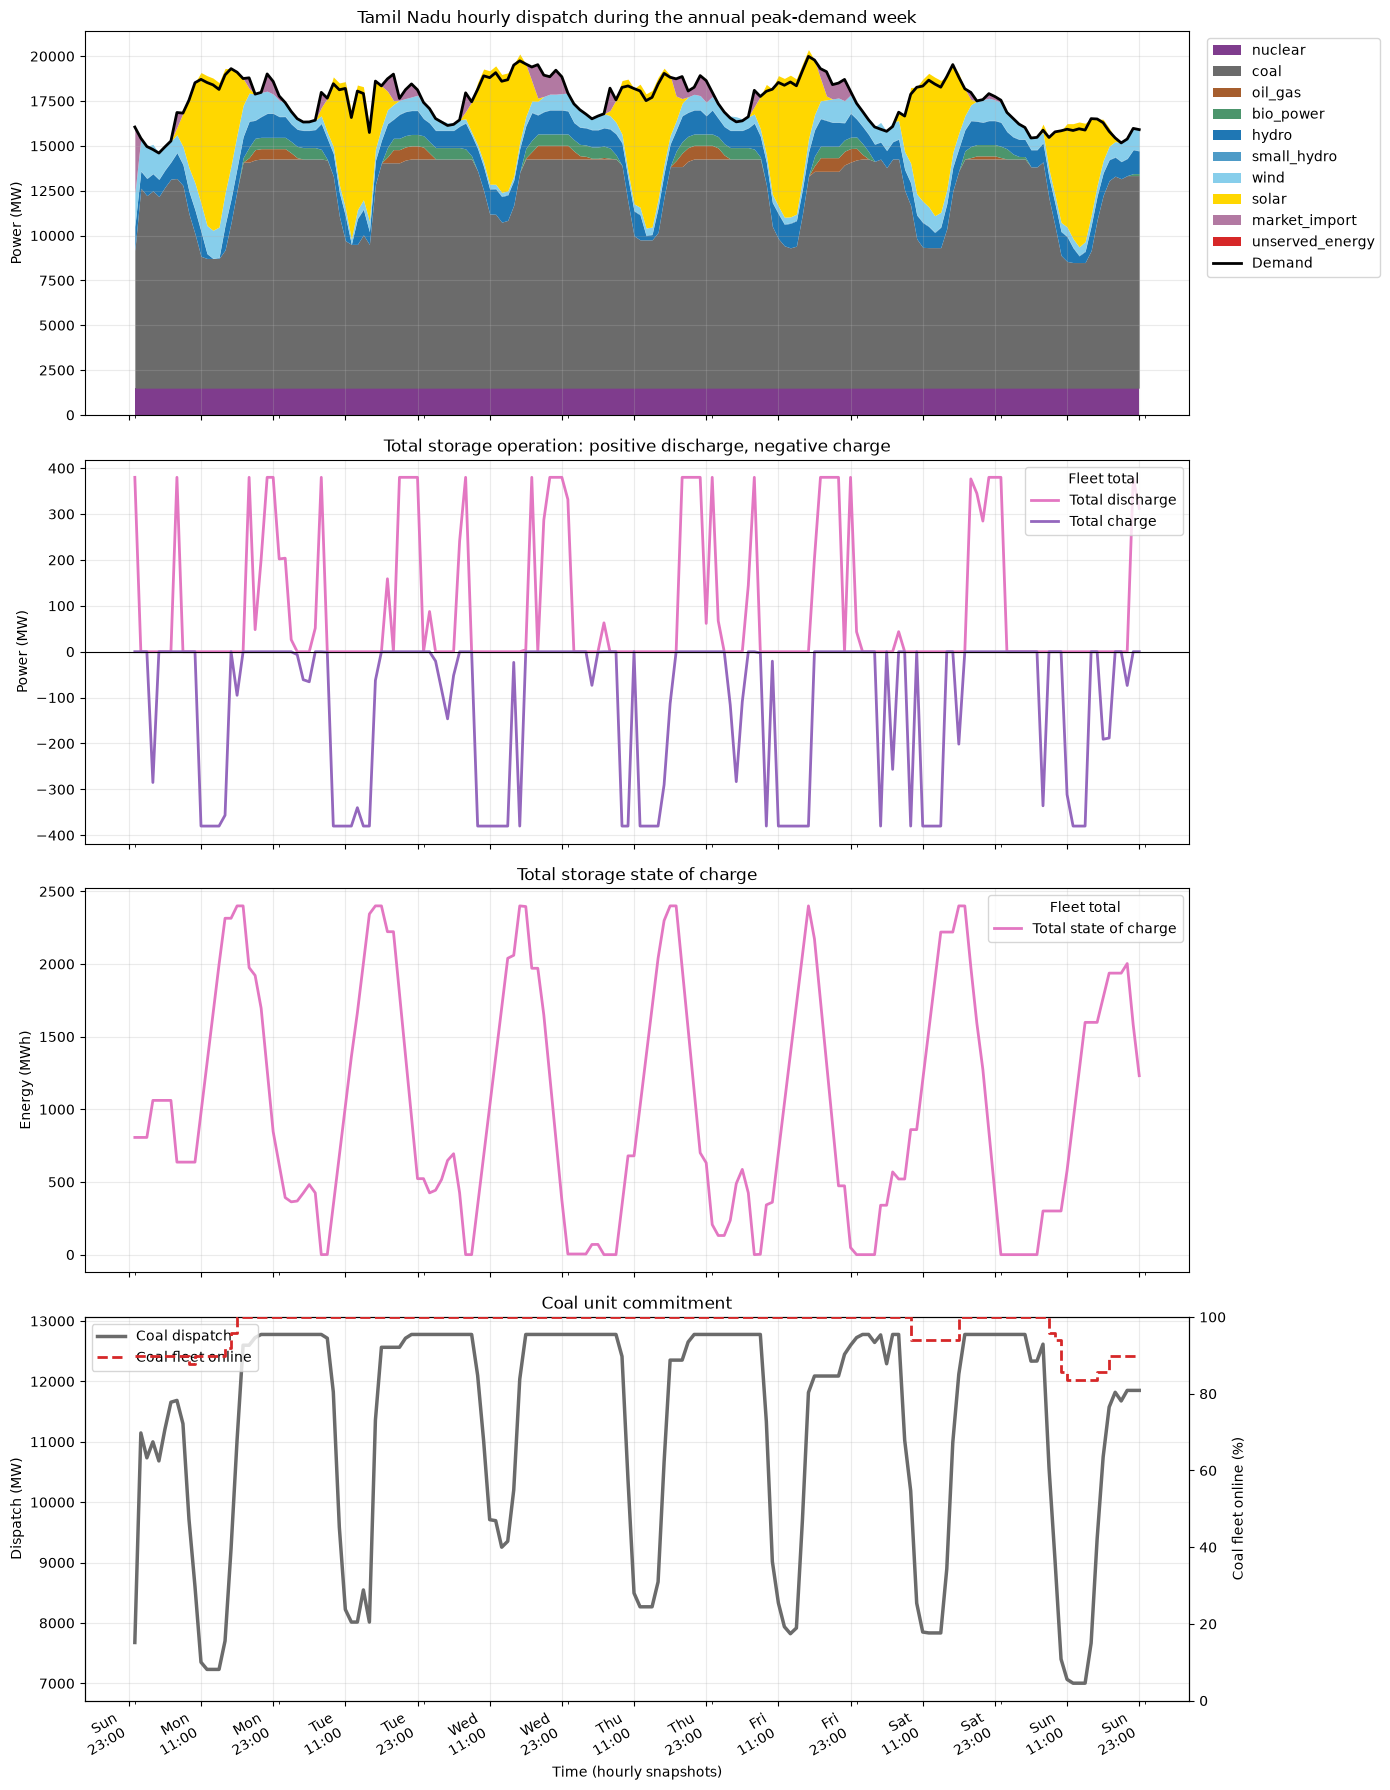

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

n

# Intuitive, consistent carrier colors used throughout the analysis
carrier_colors = {
    "nuclear": "#7F3C8D",       # purple
    "coal": "#6B6B6B",          # grey
    "oil_gas": "#A65E2E",       # brown
    "bio_power": "#4C956C",     # green
    "hydro": "#1F77B4",         # blue
    "small_hydro": "#4E9BC7",   # medium blue
    "wind": "#87CEEB",          # light blue
    "solar": "#FFD700",         # yellow
    "market_import": "#B279A2", # mauve
    "battery": "#E377C2",       # pink
    "unserved_energy": "#D62728",  # red
}

# Aggregate generator dispatch by carrier
generation = (
    n.generators_t.p
    .T.groupby(n.generators["carrier"])
    .sum().T
    .clip(lower=0)
)

# Storage: positive = discharge, negative = charge
storage_power = n.storage_units_t.p
storage_discharge = (
    storage_power.clip(lower=0)
    .T.groupby(n.storage_units["carrier"])
    .sum().T
)

supply = generation.add(storage_discharge, fill_value=0)
demand = n.loads_t.p_set.sum(axis=1)

carrier_order = [
    "nuclear", "coal", "oil_gas", "bio_power", "hydro",
    "small_hydro", "wind", "solar", "market_import",
    "battery", "unserved_energy",
]
carrier_order = [c for c in carrier_order if c in supply.columns]
supply = supply[carrier_order]

fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

# 1. Total system dispatch
supply.plot.area(
    ax=axes[0], stacked=True, linewidth=0,
    color=[carrier_colors[carrier] for carrier in supply.columns],
    x_compat=True,
)
demand.plot(
    ax=axes[0], color="black", linewidth=2, label="Demand", x_compat=True
)
axes[0].set_title("Tamil Nadu hourly dispatch during the annual peak-demand week")
axes[0].set_ylabel("Power (MW)")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1))

# 2. Total storage charge and discharge across all units
storage_operation = pd.DataFrame({
    "Total discharge": storage_power.clip(lower=0).sum(axis=1),
    "Total charge": storage_power.clip(upper=0).sum(axis=1),
})
storage_operation.plot(
    ax=axes[1], linewidth=2, color=[carrier_colors["battery"], "#9467BD"],
    x_compat=True,
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Total storage operation: positive discharge, negative charge")
axes[1].set_ylabel("Power (MW)")
axes[1].legend(title="Fleet total")

# 3. Total storage state of charge across all units
total_soc = n.storage_units_t.state_of_charge.sum(axis=1)
total_soc.plot(
    ax=axes[2], linewidth=2, color=carrier_colors["battery"],
    label="Total state of charge", x_compat=True,
)
axes[2].set_title("Total storage state of charge")
axes[2].set_ylabel("Energy (MWh)")
axes[2].legend(title="Fleet total")

# 4. Coal dispatch and committed record-level units
coal_units = n.generators.index[n.generators.carrier == "coal"]
coal_dispatch = n.generators_t.p[coal_units].sum(axis=1)
coal_online_pct = 100 * n.generators_t.status[coal_units].sum(axis=1) / len(coal_units)

coal_dispatch.plot(
    ax=axes[3], color=carrier_colors["coal"], linewidth=2.5,
    label="Coal dispatch", zorder=3, x_compat=True,
)
axes[3].set_title("Coal unit commitment")
axes[3].set_ylabel("Dispatch (MW)")

commitment_axis = axes[3].twinx()
coal_online_pct.plot(
    ax=commitment_axis, drawstyle="steps-post", color="tab:red",
    linewidth=2, linestyle="--", label="Coal fleet online",
    zorder=4, x_compat=True,
)
commitment_axis.set_ylabel("Coal fleet online (%)")
commitment_axis.set_ylim(0, 100)

lines1, labels1 = axes[3].get_legend_handles_labels()
lines2, labels2 = commitment_axis.get_legend_handles_labels()
axes[3].legend(lines1 + lines2, labels1 + labels2, loc="upper left")

axes[3].xaxis.set_major_locator(mdates.HourLocator(interval=12))
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%a\n%H:%M"))
axes[3].set_xlabel("Time (hourly snapshots)")
axes[3].grid(alpha=0.25)

for ax in axes[:3]:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Forced-outage impact

This section compares the solved network's generator availability with the original hourly input profiles. Any reduction in `p_max_pu` is interpreted as forced unavailability. The first panel repeats the system dispatch figure and overlays forced unavailable capacity, with outage hours shaded. The remaining panels show unavailable capacity by carrier, the response from imports, storage, and unserved energy, and coal dispatch together with the percentage of coal units committed.

A positive unserved-energy result is a direct reliability impact. If unserved energy remains zero, the system found enough replacement supply for these outages. An exact outage-attributable production-cost difference would require a separately solved no-outage counterfactual.

INFO:pypsa.network.io:Imported network 'Tamil Nadu FY 2025-26 single-node UC inputs' has buses, carriers, generators, loads, storage_units


Forced-outage events detected: 10
Maximum simultaneous unavailable capacity: 782.0 MW at 2025-07-07 04:00:00
Unavailable capacity at the demand peak (2025-07-11 16:00:00): 742.5 MW
Unavailable capacity-hours: 23,112.5 MW-hours
Unserved energy in the outage case: 0.000 MWh
No load shedding occurred; replacement supply covered the outages.


,generator,carrier,capacity_MW,fault_start,available_again,duration_h,max_unavailable_MW
0,neyveli_tps_ii__unit_05,coal,210.0,2025-07-07 00:00:00,2025-07-07 05:00:00,5.0,178.5
1,tuticorin_joint_venture__unit_02,coal,500.0,2025-07-07 00:00:00,2025-07-07 15:00:00,15.0,425.0
2,tuticorin_tps__unit_04,coal,210.0,2025-07-07 04:00:00,2025-07-07 20:00:00,16.0,178.5
3,basin_bridge_gas_turbine_power_station__unit_02,oil_gas,30.0,2025-07-08 09:00:00,2025-07-09 02:00:00,17.0,27.0
4,neyveli_ext_tps_ii__unit_01,coal,250.0,2025-07-08 09:00:00,2025-07-08 21:00:00,12.0,212.5
5,tuticorin_tps__unit_02,coal,210.0,2025-07-08 11:00:00,2025-07-08 16:00:00,5.0,178.5
6,vallur_tpp__unit_02,coal,500.0,2025-07-10 16:00:00,2025-07-10 20:00:00,4.0,425.0
7,mettur_tps__unit_05,coal,600.0,2025-07-11 12:00:00,2025-07-11 22:00:00,10.0,510.0
8,valuthur_gas_turbine_power_station__unit_01,oil_gas,60.0,2025-07-11 12:00:00,2025-07-11 18:00:00,6.0,54.0
9,mettur_tps__unit_03,coal,210.0,2025-07-11 13:00:00,2025-07-12 00:00:00,11.0,178.5


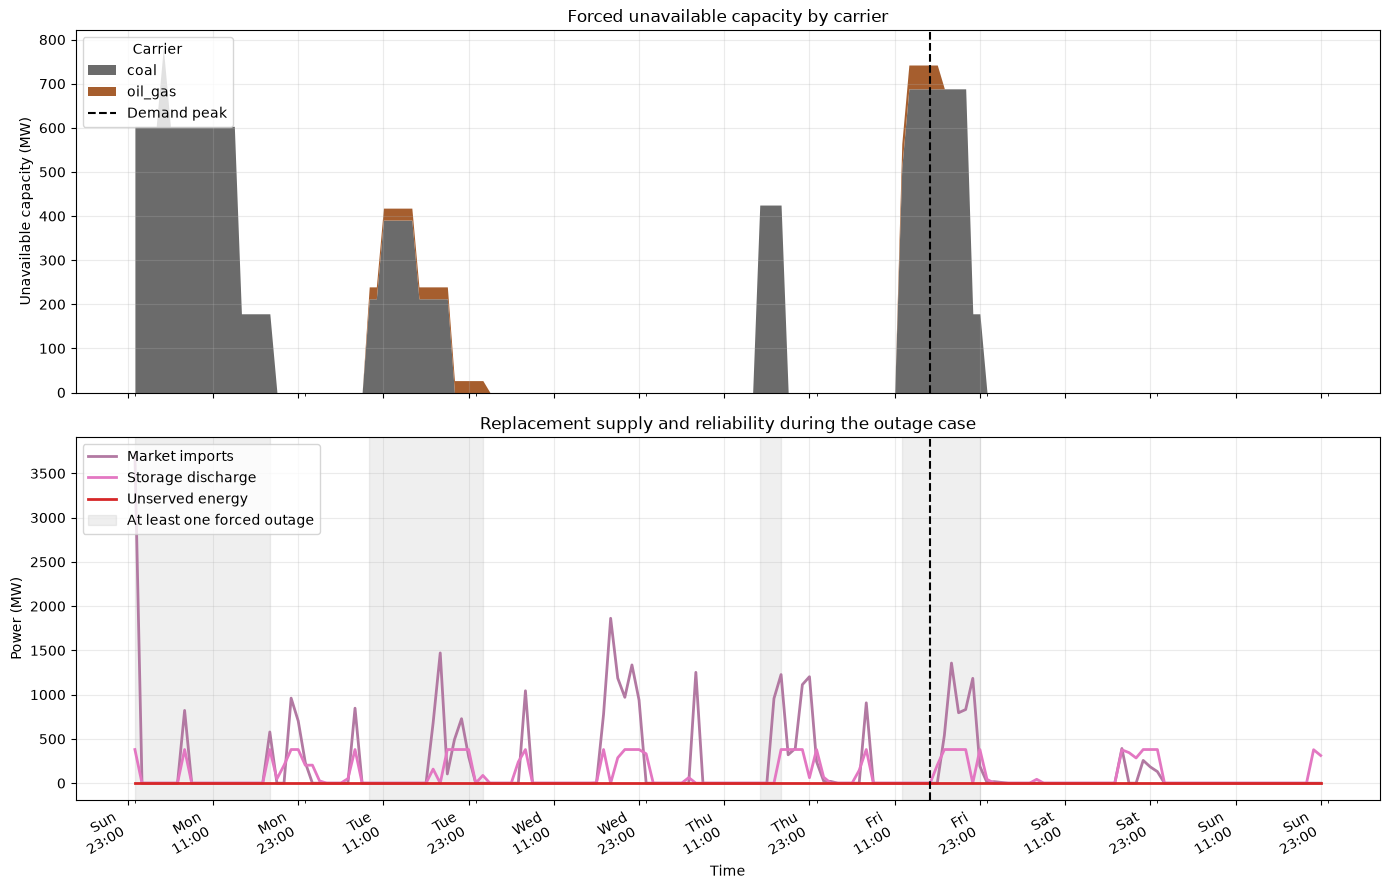

In [26]:
BASE_INPUT = "inputs/tamil_nadu_ra_2025_26"
outage_carriers = ["coal", "nuclear", "oil_gas"]
base_network = pypsa.Network(BASE_INPUT)

eligible_outage_units = n.generators.index[
    n.generators.carrier.isin(outage_carriers) & n.generators.active
]


def dense_generator_limit(network, attribute, units, snapshots):
    """Return static and time-varying generator limits as one dense table."""
    time_series = getattr(network.generators_t, attribute)
    result = pd.DataFrame(index=snapshots, columns=units, dtype=float)
    for unit in units:
        static_value = float(network.generators.at[unit, attribute])
        if unit in time_series.columns:
            result[unit] = time_series[unit].reindex(snapshots).fillna(static_value)
        else:
            result[unit] = static_value
    return result


baseline_p_max_pu = dense_generator_limit(
    base_network, "p_max_pu", eligible_outage_units, n.snapshots
)
result_p_max_pu = dense_generator_limit(
    n, "p_max_pu", eligible_outage_units, n.snapshots
)
forced_reduction_pu = (baseline_p_max_pu - result_p_max_pu).clip(lower=0.0)
forced_reduction_pu = forced_reduction_pu.mask(forced_reduction_pu < 1e-9, 0.0)
unavailable_capacity_mw = forced_reduction_pu.mul(
    n.generators.loc[eligible_outage_units, "p_nom"], axis=1
)
total_unavailable_mw = unavailable_capacity_mw.sum(axis=1)

# Convert consecutive unavailable snapshots for each unit into an event table.
snapshot_duration = n.snapshots.to_series().diff().dropna().median()
snapshot_hours = snapshot_duration / pd.Timedelta(hours=1)
event_records = []
for unit in eligible_outage_units:
    unavailable = forced_reduction_pu[unit] > 0.0
    event_groups = unavailable.ne(unavailable.shift(fill_value=False)).cumsum()
    for _, event in unavailable[unavailable].groupby(event_groups[unavailable]):
        event_snapshots = event.index
        event_records.append(
            {
                "generator": unit,
                "carrier": n.generators.at[unit, "carrier"],
                "capacity_MW": n.generators.at[unit, "p_nom"],
                "fault_start": event_snapshots[0],
                "available_again": event_snapshots[-1] + snapshot_duration,
                "duration_h": len(event_snapshots) * snapshot_hours,
                "max_unavailable_MW": unavailable_capacity_mw.loc[
                    event_snapshots, unit
                ].max(),
            }
        )

outage_events = pd.DataFrame(event_records)
if not outage_events.empty:
    outage_events = outage_events.sort_values(
        ["fault_start", "generator"]
    ).reset_index(drop=True)

snapshot_weights = n.snapshot_weightings.generators
unavailable_capacity_hours = (total_unavailable_mw * snapshot_weights).sum()
unserved = generation.get(
    "unserved_energy", pd.Series(0.0, index=n.snapshots)
)
outage_case_unserved_mwh = (unserved * snapshot_weights).sum()

if outage_events.empty:
    print("No forced outages were detected relative to the original input profiles.")
else:
    peak_outage_time = total_unavailable_mw.idxmax()
    demand_peak_time = demand.idxmax()
    print(f"Forced-outage events detected: {len(outage_events)}")
    print(f"Maximum simultaneous unavailable capacity: "
          f"{total_unavailable_mw.max():,.1f} MW at {peak_outage_time}")
    print(f"Unavailable capacity at the demand peak ({demand_peak_time}): "
          f"{total_unavailable_mw.at[demand_peak_time]:,.1f} MW")
    print(f"Unavailable capacity-hours: {unavailable_capacity_hours:,.1f} MW-hours")
    print(f"Unserved energy in the outage case: {outage_case_unserved_mwh:,.3f} MWh")
    if outage_case_unserved_mwh > 1e-6:
        print("Reliability impact detected: some demand could not be served.")
    else:
        print("No load shedding occurred; replacement supply covered the outages.")

    display(outage_events)

    outage_by_carrier = (
        unavailable_capacity_mw.T
        .groupby(n.generators.loc[eligible_outage_units, "carrier"])
        .sum().T
    )
    outage_by_carrier = outage_by_carrier.loc[
        :, outage_by_carrier.max(axis=0) > 1e-9
    ]
    response = pd.DataFrame(
        {
            "Market imports": generation.get(
                "market_import", pd.Series(0.0, index=n.snapshots)
            ),
            "Storage discharge": storage_discharge.sum(axis=1),
            "Unserved energy": unserved,
        }
    )

    fig, outage_axes = plt.subplots(4, 1, figsize=(15, 20), sharex=True)

    supply.plot.area(
        ax=outage_axes[0], stacked=True, linewidth=0,
        color=[carrier_colors[carrier] for carrier in supply.columns],
        x_compat=True,
    )
    demand.plot(
        ax=outage_axes[0], color="black", linewidth=2, label="Demand",
        x_compat=True,
    )
    dispatch_outage_axis = outage_axes[0].twinx()
    total_unavailable_mw.plot(
        ax=dispatch_outage_axis, color="#D62728", linewidth=2.2,
        linestyle="--", label="Forced unavailable capacity", x_compat=True,
    )
    outage_axes[0].fill_between(
        n.snapshots, 0, 1, where=(total_unavailable_mw > 0).to_numpy(),
        transform=outage_axes[0].get_xaxis_transform(), color="#D62728",
        alpha=0.08, label="Forced-outage hours",
    )
    outage_axes[0].axvline(
        demand_peak_time, color="black", linestyle=":", linewidth=1.5,
        label="Demand peak",
    )
    outage_axes[0].set_title("System dispatch with forced outages")
    outage_axes[0].set_ylabel("Dispatch and demand (MW)")
    dispatch_outage_axis.set_ylabel("Forced unavailable capacity (MW)", color="#D62728")
    dispatch_outage_axis.tick_params(axis="y", colors="#D62728")
    dispatch_lines, dispatch_labels = outage_axes[0].get_legend_handles_labels()
    outage_lines, outage_labels = dispatch_outage_axis.get_legend_handles_labels()
    outage_axes[0].legend(
        dispatch_lines + outage_lines, dispatch_labels + outage_labels,
        loc="upper left", bbox_to_anchor=(1.08, 1),
    )

    outage_by_carrier.plot.area(
        ax=outage_axes[1], stacked=True, linewidth=0,
        color=[carrier_colors.get(carrier, "#999999")
               for carrier in outage_by_carrier.columns],
        x_compat=True,
    )
    outage_axes[1].set_title("Forced unavailable capacity by carrier")
    outage_axes[1].set_ylabel("Unavailable capacity (MW)")
    outage_axes[1].axvline(
        demand_peak_time, color="black", linestyle="--", linewidth=1.5,
        label="Demand peak",
    )
    outage_axes[1].legend(title="Carrier", loc="upper left")

    response.plot(
        ax=outage_axes[2], linewidth=2,
        color=[carrier_colors["market_import"], carrier_colors["battery"],
               carrier_colors["unserved_energy"]],
        x_compat=True,
    )
    outage_axes[2].fill_between(
        n.snapshots, 0, 1, where=(total_unavailable_mw > 0).to_numpy(),
        transform=outage_axes[2].get_xaxis_transform(), color="grey", alpha=0.12,
        label="At least one forced outage",
    )
    outage_axes[2].set_title("Replacement supply and reliability during the outage case")
    outage_axes[2].set_ylabel("Power (MW)")
    outage_axes[2].set_xlabel("Time")
    outage_axes[2].legend(loc="upper left")
    outage_axes[2].axvline(
        demand_peak_time, color="black", linestyle="--", linewidth=1.5,
    )

    coal_dispatch.plot(
        ax=outage_axes[3], color=carrier_colors["coal"], linewidth=2.5,
        label="Coal dispatch", zorder=3, x_compat=True,
    )
    outage_coal_commitment_axis = outage_axes[3].twinx()
    coal_online_pct.plot(
        ax=outage_coal_commitment_axis, drawstyle="steps-post",
        color="tab:red", linewidth=2, linestyle="--",
        label="Coal fleet online", zorder=4, x_compat=True,
    )
    outage_axes[3].fill_between(
        n.snapshots, 0, 1, where=(total_unavailable_mw > 0).to_numpy(),
        transform=outage_axes[3].get_xaxis_transform(), color="#D62728",
        alpha=0.08, label="Forced-outage hours",
    )
    outage_axes[3].axvline(
        demand_peak_time, color="black", linestyle=":", linewidth=1.5,
        label="Demand peak",
    )
    outage_axes[3].set_title("Coal unit commitment during the outage case")
    outage_axes[3].set_ylabel("Coal dispatch (MW)")
    outage_axes[3].set_xlabel("Time")
    outage_coal_commitment_axis.set_ylabel("Coal fleet online (%)")
    outage_coal_commitment_axis.set_ylim(0, 100)
    coal_lines, coal_labels = outage_axes[3].get_legend_handles_labels()
    commitment_lines, commitment_labels = (
        outage_coal_commitment_axis.get_legend_handles_labels()
    )
    outage_axes[3].legend(
        coal_lines + commitment_lines, coal_labels + commitment_labels,
        loc="upper left",
    )

    for axis in outage_axes:
        axis.grid(alpha=0.25)
    outage_axes[3].xaxis.set_major_locator(mdates.HourLocator(interval=12))
    outage_axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%a\n%H:%M"))
    plt.tight_layout()
    plt.show()

## Wind and solar generation

These graphs compare variable renewable generation at two time scales. Wind is light blue and solar is yellow.

1. **Peak-demand day:** The upper graph isolates the day containing the week's maximum demand. It shows the hourly solar cycle and how wind output varies during that day.
2. **Full peak week:** The lower graph shows the same two technologies across all seven days, making day-to-day changes and periods of simultaneously low renewable output easier to identify.

The lines show actual modeled generation, so they reflect both available renewable resources and any curtailment in the optimization result.


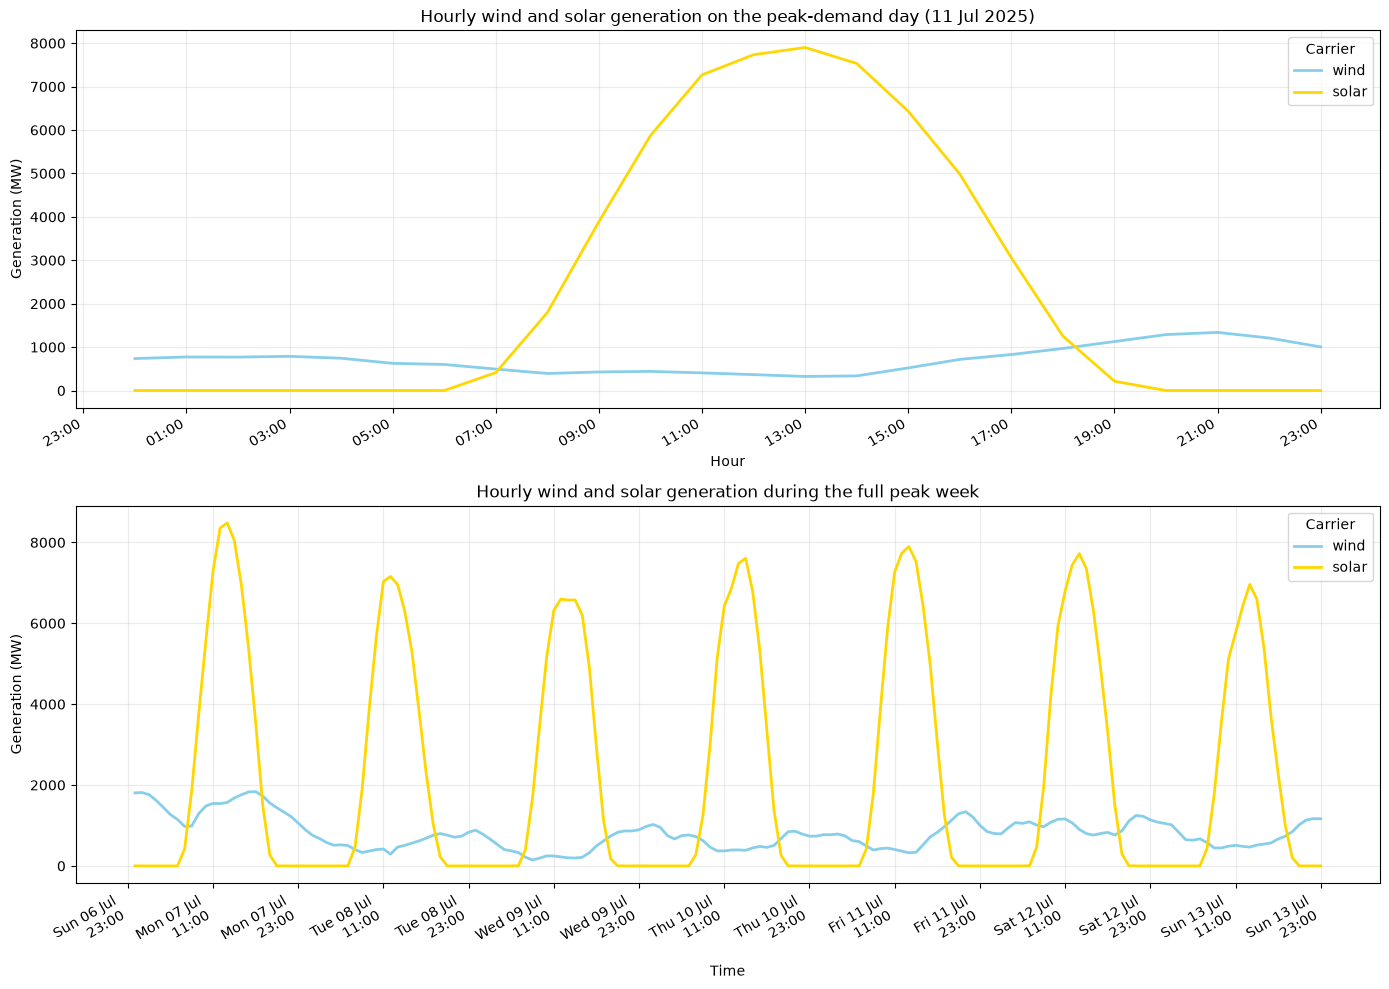

In [27]:
vre_plot = generation.reindex(columns=["wind", "solar"], fill_value=0)

peak_day = demand.idxmax().normalize()
peak_day_end = peak_day + pd.Timedelta(days=1)
vre_peak_day = vre_plot.loc[
    (vre_plot.index >= peak_day) & (vre_plot.index < peak_day_end)
]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

vre_peak_day.plot(
    ax=axes[0],
    linewidth=2,
    color={carrier: carrier_colors[carrier] for carrier in vre_plot.columns},
    x_compat=True,
)
axes[0].set_title(
    f"Hourly wind and solar generation on the peak-demand day "
    f"({peak_day:%d %b %Y})"
)
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Generation (MW)")
axes[0].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[0].legend(title="Carrier")
axes[0].grid(alpha=0.25)

vre_plot.plot(
    ax=axes[1],
    linewidth=2,
    color={carrier: carrier_colors[carrier] for carrier in vre_plot.columns},
    x_compat=True,
)
axes[1].set_title("Hourly wind and solar generation during the full peak week")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Generation (MW)")
axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=12))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b\n%H:%M"))
axes[1].legend(title="Carrier")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Evening flexibility and ramp adequacy

Net load is demand minus wind and solar generation. Its increase between consecutive hourly snapshots is the response that dispatchable generators and storage must provide. For committable generators, the calculation below reproduces PyPSA's applicable upward-ramp allowance: the normal ramp limit for units already online and the start-up ramp limit for units starting in that interval.

> **Resolution limitation:** these ramps are changes between consecutive hourly averages. They describe hourly flexibility requirements but cannot reveal intra-hour variability or sub-hourly ramping constraints.

In [28]:
vre_carriers = ["solar", "wind"]
dispatchable_carriers = [
    "coal", "oil_gas", "bio_power", "hydro",
    "small_hydro", "market_import",
]

generation_by_carrier = (
    n.generators_t.p.T.groupby(n.generators.carrier).sum().T.clip(lower=0)
)
vre_generation = generation_by_carrier.reindex(columns=vre_carriers, fill_value=0).sum(axis=1)
net_load = demand - vre_generation
net_load_ramp = net_load.diff()  # MW change between consecutive hourly averages

dispatchable_generation = generation_by_carrier.reindex(
    columns=dispatchable_carriers, fill_value=0
).sum(axis=1)
storage_response = n.storage_units_t.p.sum(axis=1)
dispatchable_response = dispatchable_generation + storage_response
dispatchable_response_ramp = dispatchable_response.diff()

# Reconstruct the exact upward allowance used for fixed-capacity committable units.
ramp_units = n.generators.index[
    n.generators.committable & n.generators.ramp_limit_up.notna()
]
unit_dispatch = n.generators_t.p[ramp_units]
unit_status = n.generators_t.status[ramp_units].round()
previous_dispatch = unit_dispatch.shift(1)
previous_status = unit_status.shift(1)
unit_increase = unit_dispatch - previous_dispatch
status_change = unit_status - previous_status

p_nom = n.generators.loc[ramp_units, "p_nom"]
normal_up = n.generators.loc[ramp_units, "ramp_limit_up"]
start_up = n.generators.loc[ramp_units, "ramp_limit_start_up"]
allowed_up = (
    previous_status.mul(p_nom * normal_up, axis=1)
    + status_change.mul(p_nom * start_up, axis=1)
)
upward_ramp_utilization = unit_increase.where(unit_increase > 1e-6).div(
    allowed_up.where(allowed_up > 0)
)
binding_up_units = upward_ramp_utilization.ge(0.95).sum(axis=1)
starting_units = status_change.gt(0.5).sum(axis=1)
max_up_utilization = upward_ramp_utilization.max(axis=1).clip(upper=1.0)

unserved = generation_by_carrier.get(
    "unserved_energy", pd.Series(0.0, index=n.snapshots)
)
unserved_mwh = (unserved * n.snapshot_weightings.generators).sum()
evening = net_load_ramp.index.hour.isin(range(15, 22))
peak_ramp_time = net_load_ramp.loc[evening].idxmax()

print(f"Largest evening net-load increase: {net_load_ramp.at[peak_ramp_time]:,.1f} MW/h "
      f"at {peak_ramp_time}")
print(f"Dispatchable response in that interval: "
      f"{dispatchable_response_ramp.at[peak_ramp_time]:,.1f} MW")
print(f"Thermal units starting: {starting_units.at[peak_ramp_time]:.0f}; "
      f"at or above 95% of upward ramp allowance: {binding_up_units.at[peak_ramp_time]:.0f}")
print(f"Unserved energy over the week: {unserved_mwh:,.3f} MWh")


Largest evening net-load increase: 4,275.7 MW/h at 2025-07-08 16:00:00
Dispatchable response in that interval: 4,275.7 MW
Thermal units starting: 0; at or above 95% of upward ramp allowance: 1
Unserved energy over the week: 0.000 MWh


### How to read the flexibility and ramp graphs

This three-panel figure examines whether dispatchable generation and storage can follow hourly changes in net load:

1. **Demand, renewables, and net load:** Demand is the black line. Wind and solar generation are combined in the orange line. Net load is demand minus wind and solar, so the purple line represents the demand that must be met by dispatchable generators, imports, and storage.
2. **System ramp requirement and response:** The purple line is the change in net load from one hourly snapshot to the next. Positive values require supply to increase; negative values require it to decrease. The dashed green line shows the corresponding response from dispatchable generators and storage.
3. **Unit ramp utilization:** The red line and left axis show the highest share of any committed unit's applicable upward-ramp allowance used in each hour. The dotted 95% line highlights hours close to the modeled limit. The blue stepped line and right axis count units at or above 95% utilization. Yellow shading marks the 15:00–21:00 evening period, when solar output falls and flexibility is especially important.

These are changes between hourly averages; they cannot reveal faster intra-hour ramps.


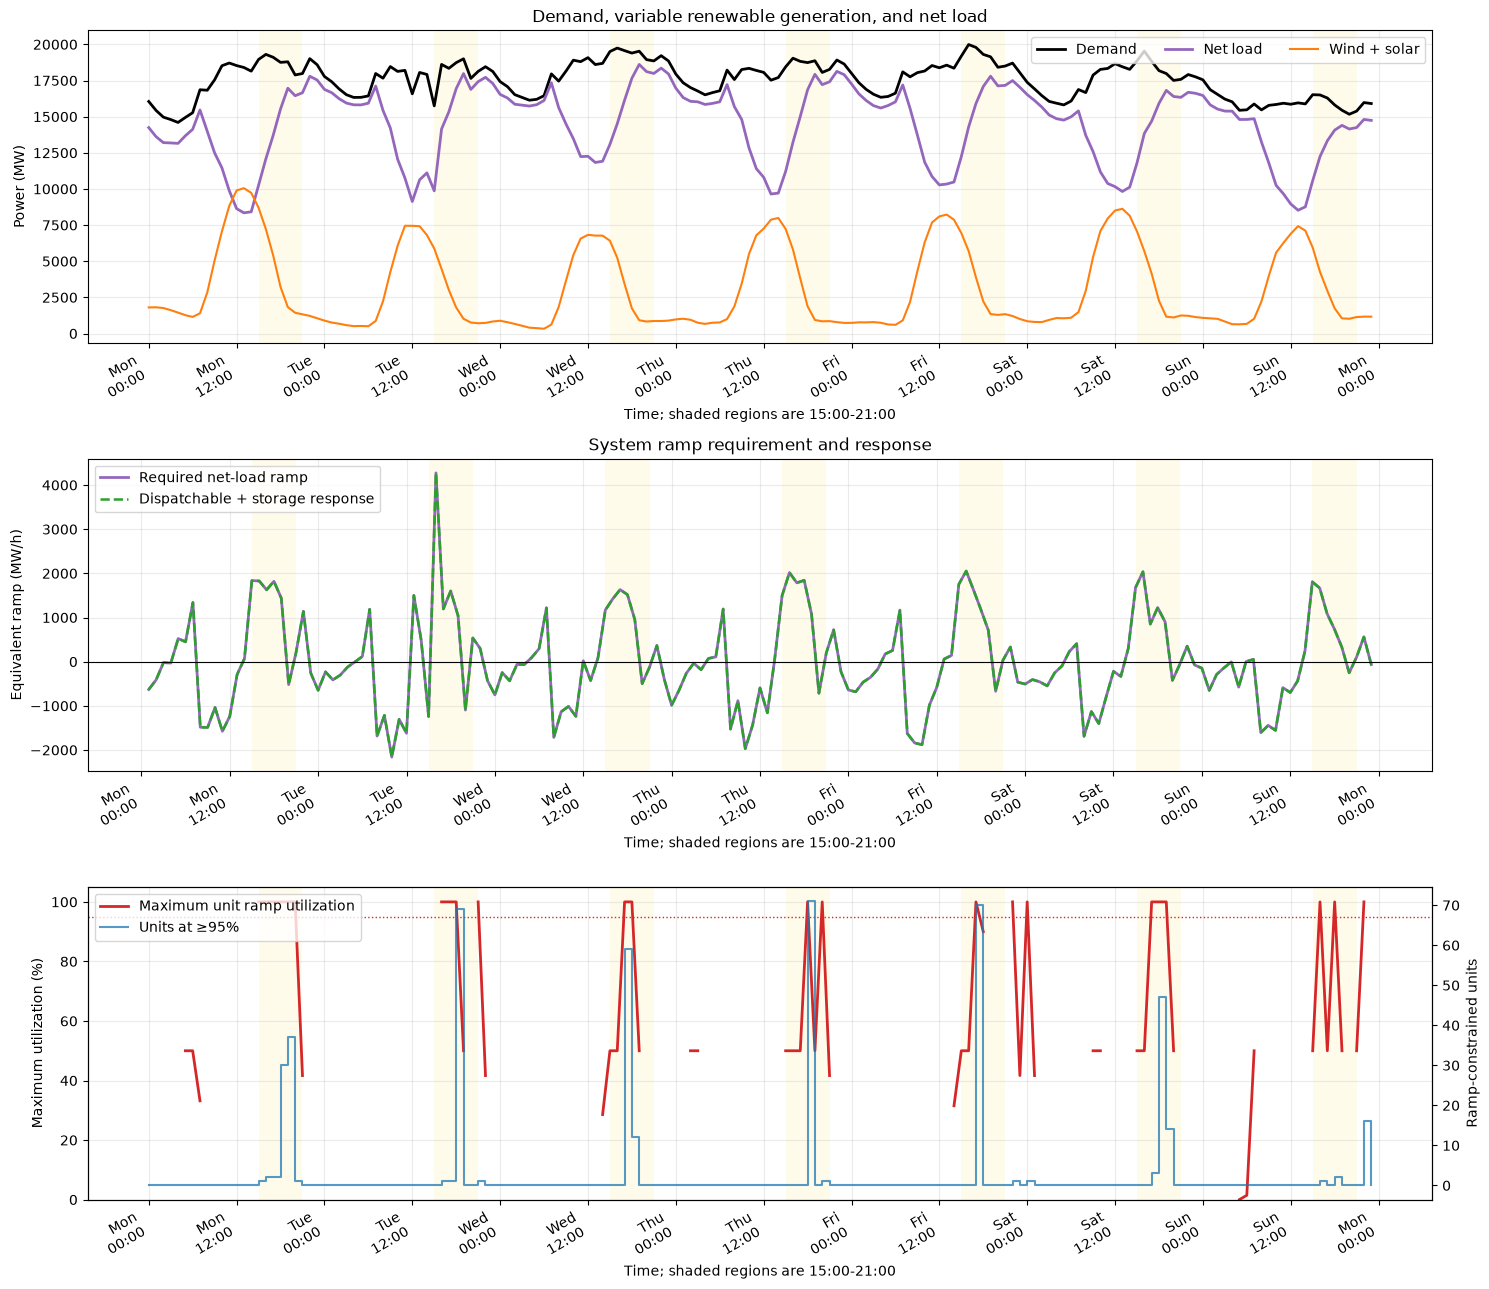

In [29]:
fig, ramp_axes = plt.subplots(3, 1, figsize=(15, 13), sharex=False)

demand.plot(ax=ramp_axes[0], color="black", linewidth=2, label="Demand", x_compat=True)
net_load.plot(ax=ramp_axes[0], color="tab:purple", linewidth=2, label="Net load", x_compat=True)
vre_generation.plot(ax=ramp_axes[0], color="tab:orange", label="Wind + solar", x_compat=True)
ramp_axes[0].set_ylabel("Power (MW)")
ramp_axes[0].set_title("Demand, variable renewable generation, and net load")
ramp_axes[0].legend(ncol=3)

net_load_ramp.plot(
    ax=ramp_axes[1], color="tab:purple", linewidth=2,
    label="Required net-load ramp", x_compat=True,
)
dispatchable_response_ramp.plot(
    ax=ramp_axes[1], color="tab:green", linestyle="--", linewidth=1.8,
    label="Dispatchable + storage response", x_compat=True,
)
ramp_axes[1].axhline(0, color="black", linewidth=0.8)
ramp_axes[1].set_ylabel("Equivalent ramp (MW/h)")
ramp_axes[1].set_title("System ramp requirement and response")
ramp_axes[1].legend()

(100 * max_up_utilization).plot(
    ax=ramp_axes[2], color="tab:red", linewidth=2,
    label="Maximum unit ramp utilization", x_compat=True,
)
ramp_axes[2].axhline(95, color="tab:red", linestyle=":", linewidth=1)
ramp_axes[2].set_ylim(0, 105)
ramp_axes[2].set_ylabel("Maximum utilization (%)")
binding_axis = ramp_axes[2].twinx()
binding_up_units.plot(
    ax=binding_axis, color="tab:blue", drawstyle="steps-post",
    alpha=0.75, label="Units at ≥95%", x_compat=True,
)
binding_axis.set_ylabel("Ramp-constrained units")

for day in pd.DatetimeIndex(n.snapshots.normalize().unique()):
    for ax in ramp_axes:
        ax.axvspan(
            day + pd.Timedelta(hours=15), day + pd.Timedelta(hours=21),
            color="gold", alpha=0.08, linewidth=0,
        )
for ax in ramp_axes:
    ax.grid(alpha=0.25)

lines1, labels1 = ramp_axes[2].get_legend_handles_labels()
lines2, labels2 = binding_axis.get_legend_handles_labels()
ramp_axes[2].legend(lines1 + lines2, labels1 + labels2, loc="upper left")
tick_positions = pd.date_range(
    n.snapshots[0].normalize(), n.snapshots[-1].ceil("12h"), freq="12h"
)
for ax in ramp_axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([timestamp.strftime("%a\n%H:%M") for timestamp in tick_positions])
    ax.set_xlabel("Time; shaded regions are 15:00-21:00")
plt.tight_layout()
plt.show()

In [30]:
carrier_ramps = generation_by_carrier.reindex(
    columns=dispatchable_carriers, fill_value=0
).diff()
interval_summary = pd.DataFrame({
    "net_load_ramp_mw_per_hour": net_load_ramp,
    "dispatchable_response_mw": dispatchable_response_ramp,
    "coal_response_mw": carrier_ramps["coal"],
    "oil_gas_response_mw": carrier_ramps["oil_gas"],
    "bio_power_response_mw": carrier_ramps["bio_power"],
    "hydro_response_mw": carrier_ramps["hydro"],
    "storage_response_mw": storage_response.diff(),
    "thermal_startups": starting_units,
    "units_at_or_above_95pct_ramp": binding_up_units,
    "unserved_energy_mw": unserved,
})

print("Largest late-afternoon/evening system ramps:")
display(interval_summary.loc[evening].nlargest(10, "net_load_ramp_mw_per_hour").round(2))

unit_events = pd.DataFrame({
    "actual_increase_mw": unit_increase.stack(),
    "allowed_increase_mw": allowed_up.stack(),
    "ramp_utilization": upward_ramp_utilization.stack(),
}).dropna()
unit_events = unit_events.loc[unit_events.actual_increase_mw > 1e-6].reset_index()
unit_events.columns = ["snapshot", "generator", *unit_events.columns[2:]]
unit_events["carrier"] = unit_events.generator.map(n.generators.carrier)
unit_events["started"] = [
    bool(status_change.at[timestamp, generator] > 0.5)
    for timestamp, generator in zip(unit_events.snapshot, unit_events.generator)
]
unit_events["ramp_utilization_pct"] = (100 * unit_events.ramp_utilization).clip(upper=100)
largest_binding_events = (
    unit_events.loc[unit_events.ramp_utilization >= 0.95]
    .sort_values("actual_increase_mw", ascending=False)
    .drop(columns=["ramp_utilization"])
    .head(20)
)
print("Largest individual increases at or above 95% of the applicable ramp limit:")
display(largest_binding_events.round(2))

Largest late-afternoon/evening system ramps:


,net_load_ramp_mw_per_hour,dispatchable_response_mw,coal_response_mw,oil_gas_response_mw,bio_power_response_mw,hydro_response_mw,storage_response_mw,thermal_startups,units_at_or_above_95pct_ramp,unserved_energy_mw
snapshot,,,,,,,,,,
2025-07-08 16:00:00,4275.73,4275.73,3341.86,0.00,0.00,617.76,317.56,0,1,0.0
2025-07-11 16:00:00,2052.58,2052.58,2110.65,0.00,0.00,-56.62,0.00,0,0,0.0
2025-07-12 16:00:00,2036.60,2036.60,2094.67,0.00,0.00,-56.62,0.00,0,0,0.0
2025-07-10 16:00:00,2017.78,2017.78,1985.76,0.00,0.00,-56.62,90.10,0,0,0.0
2025-07-10 18:00:00,1842.78,1842.78,0.00,337.83,527.56,-90.11,113.39,71,71,0.0
2025-07-07 15:00:00,1835.69,1835.69,471.75,0.00,0.00,1341.25,23.60,1,1,0.0
2025-07-07 16:00:00,1827.90,1827.90,1529.57,0.00,0.00,-56.62,356.40,2,2,0.0
2025-07-07 18:00:00,1819.79,1819.79,1567.34,0.00,250.00,-90.11,94.89,30,30,0.0
2025-07-13 15:00:00,1808.58,1808.58,664.66,0.00,0.00,764.83,380.00,0,0,0.0


Largest individual increases at or above 95% of the applicable ramp limit:


C:\Users\b076218\AppData\Local\Temp\ipykernel_27604\1854146334.py:40: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(largest_binding_events.round(2))


,snapshot,generator,actual_increase_mw,allowed_increase_mw,carrier,started,ramp_utilization_pct
1021,2025-07-11 22:00:00,mettur_tps__unit_05,360.0,360.0,coal,False,100.0
72,2025-07-07 17:00:00,muthiara_tpp__unit_01,330.0,330.0,coal,True,100.0
828,2025-07-10 20:00:00,vallur_tpp__unit_02,300.0,300.0,coal,False,100.0
1080,2025-07-12 17:00:00,neyveli_new_tpp_neyveli_extension__unit_02,275.0,275.0,coal,True,100.0
1266,2025-07-13 18:00:00,tuticorin_joint_venture__unit_01,275.0,275.0,coal,True,100.0
1224,2025-07-13 16:00:00,neyveli_new_tpp_neyveli_extension__unit_02,275.0,275.0,coal,True,100.0
443,2025-07-08 21:00:00,neyveli_ext_tps_ii__unit_01,150.0,150.0,coal,False,100.0
58,2025-07-07 16:00:00,neyveli_tps_z__unit_01,137.5,137.5,coal,True,100.0
283,2025-07-08 16:00:00,tuticorin_tps__unit_02,126.0,126.0,coal,False,100.0
209,2025-07-07 20:00:00,tuticorin_tps__unit_04,126.0,126.0,coal,False,100.0
